In [1]:
%cd ..

/Users/sebastian/University/Master/third term/sem-proj/kg-token


/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from argparse import Namespace
from src.gnn import train_gnn
import itertools
import pandas as pd
from tqdm.notebook import tqdm

In [3]:
gnn_dims = [512, 1024]
user_feats=[[], ["occupation"], ["gender"], ["age"], ["occupation", "gender"], 
            ["occupation", "age"], ["gender", "age"], ["occupation", "gender", "age"]]
rating_type=["binary", "regression"]

In [4]:
from sklearn.model_selection import ParameterSampler
import random

param_dist = {
    "gnn_dims": gnn_dims,
    "user_feats": user_feats,
    "rating_type": rating_type
}

random_params = list(ParameterSampler(param_dist, n_iter=200, random_state=42))

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/sklearn/model_selection/_search.py:320: UserWarning: The total space of parameters 32 is smaller than n_iter=200. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [5]:
random_params

[{'user_feats': [], 'rating_type': 'binary', 'gnn_dims': 512},
 {'user_feats': ['occupation'], 'rating_type': 'binary', 'gnn_dims': 512},
 {'user_feats': ['gender'], 'rating_type': 'binary', 'gnn_dims': 512},
 {'user_feats': ['age'], 'rating_type': 'binary', 'gnn_dims': 512},
 {'user_feats': ['occupation', 'gender'],
  'rating_type': 'binary',
  'gnn_dims': 512},
 {'user_feats': ['occupation', 'age'],
  'rating_type': 'binary',
  'gnn_dims': 512},
 {'user_feats': ['gender', 'age'], 'rating_type': 'binary', 'gnn_dims': 512},
 {'user_feats': ['occupation', 'gender', 'age'],
  'rating_type': 'binary',
  'gnn_dims': 512},
 {'user_feats': [], 'rating_type': 'regression', 'gnn_dims': 512},
 {'user_feats': ['occupation'], 'rating_type': 'regression', 'gnn_dims': 512},
 {'user_feats': ['gender'], 'rating_type': 'regression', 'gnn_dims': 512},
 {'user_feats': ['age'], 'rating_type': 'regression', 'gnn_dims': 512},
 {'user_feats': ['occupation', 'gender'],
  'rating_type': 'regression',
  'gnn_d

In [6]:
# Base args Namespace
base_args = Namespace(
    dataset_path="/Users/sebastian/University/Master/third term/sem-proj/kg-token/data/ml-100k/",
    gnn_hidden_dim=512,
    gnn_out_dim=512,
    gnn_num_layers=4,
    gnn_dropout=0.1,
    gnn_num_heads=1,
    gnn_use_bn=False,
    gnn_aggr="sum",
    lr=0.001,
    seed=0,
    num_epochs=250,
    gnn_model="sage",
    device="cuda" if torch.cuda.is_available() else "cpu",
    rating_type="binary",
    user_feats=[],
)

results = []

for params in tqdm(random_params):
    args = base_args
    args.gnn_hidden_dim = params['gnn_dims']
    args.gnn_out_dim = params['gnn_dims']
    args.user_feats = params['user_feats']
    args.rating_type = params['rating_type']

    train_loss, train_acc, test_acc = train_gnn(args)

    results.append({
        "gnn_hidden_dim": args.gnn_hidden_dim,
        "gnn_out_dim": args.gnn_out_dim,
        "rating_type": args.rating_type,
        "user_features": args.user_feats,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_loss": train_loss,
    })

results_df = pd.DataFrame(results)

  0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

/Users/sebastian/University/Master/third term/sem-proj/kg-token/src/graph/Movielens100k.py:120: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1729805363309/work/torch/csrc/utils/tensor_new.cpp:281.)
  edge_index = torch.tensor([src, dst], dtype=torch.long)
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/torch_geometric/nn/fx.py:132: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  warnings.warn(f"Found function '{node.name}' with keyword "
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/torch_geometric/nn/fx.py:132: UserWarning: Found function 'dropou

0.6994697773064688


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

...

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/torch_geometric/nn/fx.py:132: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  warnings.warn(f"Found function '{node.name}' with keyword "
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/torch_geometric/nn/fx.py:132: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  warnings.warn(f"Found function '{node.name}' with keyword "
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/torch_geometric/nn/fx.py:132: UserWarning: Found function 'dropout_2' with keyword argument 'training'. During FX tracing, this will likely be 

1.0786747932434082


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/torch_geometric/nn/fx.py:132: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  warnings.warn(f"Found function '{node.name}' with keyword "
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/torch_geometric/nn/fx.py:132: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  warnings.warn(f"Found function '{node.name}' with keyword "
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/torch_geometric/nn/fx.py:132: UserWarning: Found function 'dropout_2' with keyword argument 'training'. During FX tracing, this will likely be 

1.0803136825561523


In [7]:
results_df = pd.DataFrame(results)

In [8]:
results_df.to_csv("res_trans_sage_features.csv")

In [9]:
results_df

,gnn_hidden_dim,gnn_out_dim,rating_type,user_features,train_accuracy,test_accuracy,train_loss
0,512,512,binary,[],0.737087,0.699470,0.516081
1,512,512,binary,[occupation],0.738898,0.704454,0.516163
2,512,512,binary,[gender],0.737187,0.700742,0.517853
3,512,512,binary,[age],0.724964,0.695652,0.544613
4,512,512,binary,"[occupation, gender]",0.736789,0.700530,0.518148
5,512,512,binary,"[occupation, age]",0.730805,0.700530,0.537938
6,512,512,binary,"[gender, age]",0.729944,0.695970,0.538295
7,512,512,binary,"[occupation, gender, age]",0.728067,0.696076,0.541897
8,512,512,regression,[],1.005840,1.059387,1.011713
9,512,512,regression,[occupation],1.006123,1.062784,1.012283


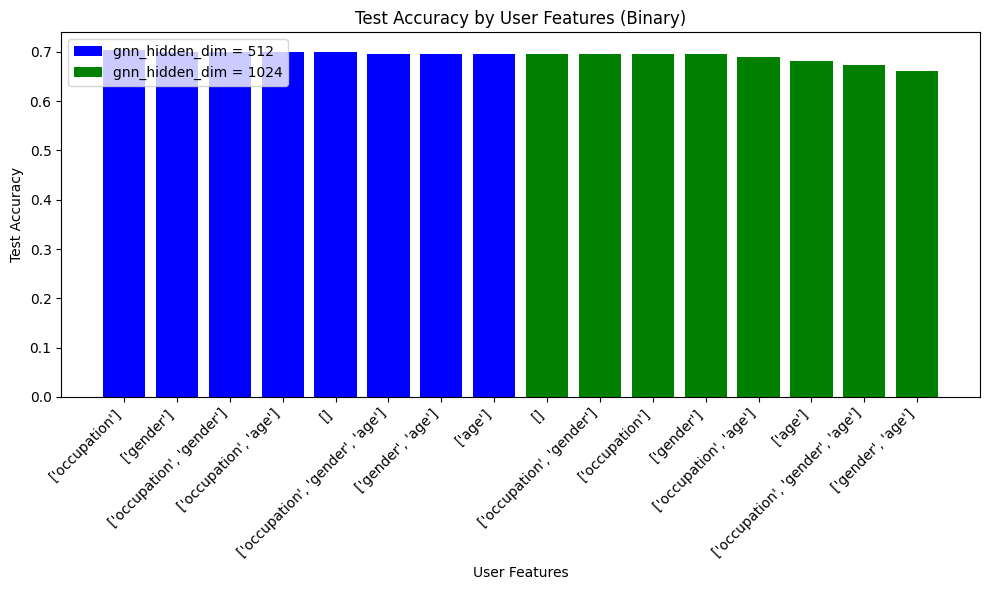

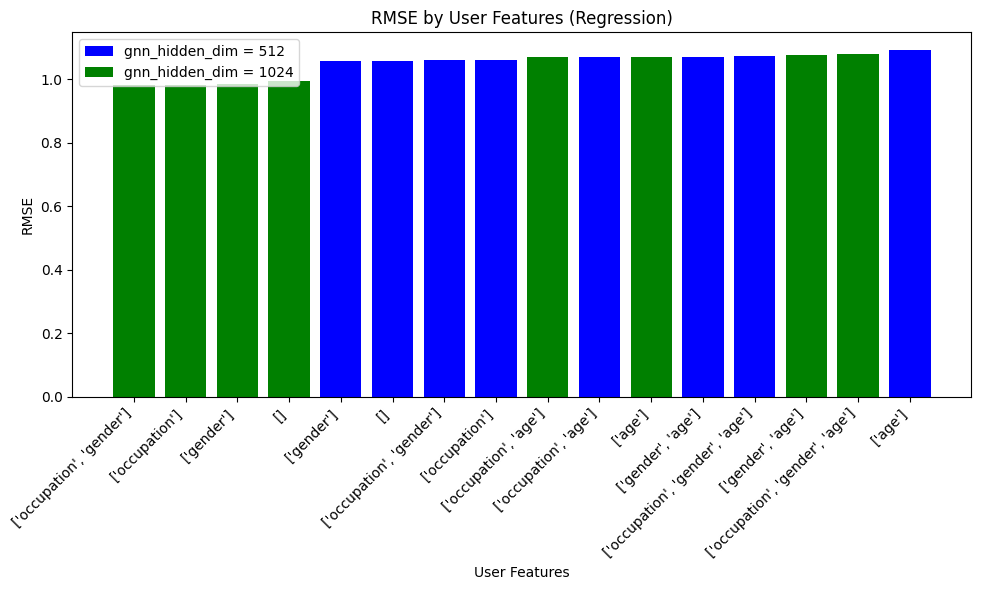

In [16]:
import matplotlib.cm as cm

color_map = {512: 'blue', 1024: 'green'}

plt.figure(figsize=(10, 6))
binary_df_sorted = binary_df.sort_values(by="test_accuracy", ascending=False)
colors = [color_map[dim] for dim in binary_df_sorted["gnn_hidden_dim"]]
bars = plt.bar(range(len(binary_df_sorted)), binary_df_sorted["test_accuracy"], color=colors, tick_label=[str(uf) for uf in binary_df_sorted["user_features"]])
plt.title("Test Accuracy by User Features (Binary)")
plt.xlabel("User Features")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")

# Add legend
plt.legend([bars[0], bars[-1]], ['gnn_hidden_dim = 512', 'gnn_hidden_dim = 1024'], loc='upper left')

plt.tight_layout()
plt.show()

# Plot test accuracy for regression rating_type with color-coded hidden_dim and legend
plt.figure(figsize=(10, 6))
regression_df_sorted = regression_df.sort_values(by="test_accuracy", ascending=True)
colors = [color_map[dim] for dim in regression_df_sorted["gnn_hidden_dim"]]
bars = plt.bar(range(len(regression_df_sorted)), regression_df_sorted["test_accuracy"], color=colors, tick_label=[str(uf) for uf in regression_df_sorted["user_features"]])
plt.title("RMSE by User Features (Regression)")
plt.xlabel("User Features")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")

# Add legend
plt.legend([bars[0], bars[-1]], ['gnn_hidden_dim = 512', 'gnn_hidden_dim = 1024'], loc='upper left')

plt.tight_layout()
plt.show()
